AI Bank Account Opening Fraud Detection

Model Evaluation

This notebook evaluates and compares the trained Machine Learning and Deep Learning models.

The notebook performs the following tasks:

- Load the trained models
- Load the testing dataset
- Generate predictions
- Evaluate each model using fraud detection metrics
- Compare model performance
- Select the best model for deployment

Import Libraries

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

Load Test Data

In [2]:
X_test = joblib.load('/content/drive/MyDrive/PROYECT_4/data/processed/X_test.pkl')
X_test_scaled = joblib.load('/content/drive/MyDrive/PROYECT_4/data/processed/X_test_scaled.pkl')
y_test = joblib.load('/content/drive/MyDrive/PROYECT_4/data/processed/y_test.pkl')

Load Trained Models

In [5]:
models = {
    'logistic_regression': joblib.load('/content/drive/MyDrive/PROYECT_4/models/logisticregression.joblib'),
    'random_forest': joblib.load('/content/drive/MyDrive/PROYECT_4/models/randomforest.joblib'),
    'xgboost': joblib.load('/content/drive/MyDrive/PROYECT_4/models/xgboost.joblib'),
    'decision_tree': joblib.load('/content/drive/MyDrive/PROYECT_4/models/decisiontree.joblib')
}

In [7]:
dnn_model = load_model('/content/drive/MyDrive/PROYECT_4/models/dnn_model.keras')

Evaluate ML Models

In [8]:
results = []

for model_name, model in models.items():
  y_prob = model.predict_proba(X_test)[:,1]
  y_pred = (y_prob >= 0.5).astype(int)

  results.append({
      'model': model_name,
      'accuracy': accuracy_score(y_test, y_pred),
      'precision': precision_score(y_test, y_pred),
      'recall': recall_score(y_test, y_pred),
      'f1_score': f1_score(y_test, y_pred),
      'roc_auc': roc_auc_score(y_test, y_pred),
      'PR_AUC': average_precision_score(y_test, y_pred)
  })

Evaluate DNN

In [9]:
y_prob_dnn = dnn_model.predict(X_test_scaled).ravel()
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)

results.append({
    'model': 'Deep Neural Network',
    'accuracy': accuracy_score(y_test, y_pred_dnn),
    'precision': precision_score(y_test, y_pred_dnn),
    'recall': recall_score(y_test, y_pred_dnn),
    'f1_score': f1_score(y_test, y_pred_dnn),
    'roc_auc': roc_auc_score(y_test, y_pred_dnn),
    'PR_AUC': average_precision_score(y_test, y_pred_dnn)
})

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


Comparing Models

In [10]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='PR_AUC', ascending=False, inplace=True)

In [11]:
results_df

,model,accuracy,precision,recall,f1_score,roc_auc,PR_AUC
4,Deep Neural Network,0.778250,0.038339,0.793651,0.073145,0.785865,0.032703
0,logistic_regression,0.784800,0.037909,0.759637,0.072214,0.772359,0.031447
2,xgboost,0.988900,0.454545,0.034014,0.063291,0.516779,0.026111
3,decision_tree,0.978250,0.063136,0.070295,0.066524,0.529333,0.014688
1,random_forest,0.988675,0.250000,0.013605,0.025806,0.506575,0.014276


Select Best Model

In [16]:
best_model_name = results_df.sort_values(by='PR_AUC', ascending=False).iloc[0]['model']

In [18]:
best_model_name

'Deep Neural Network'

PR-AUC Comparison

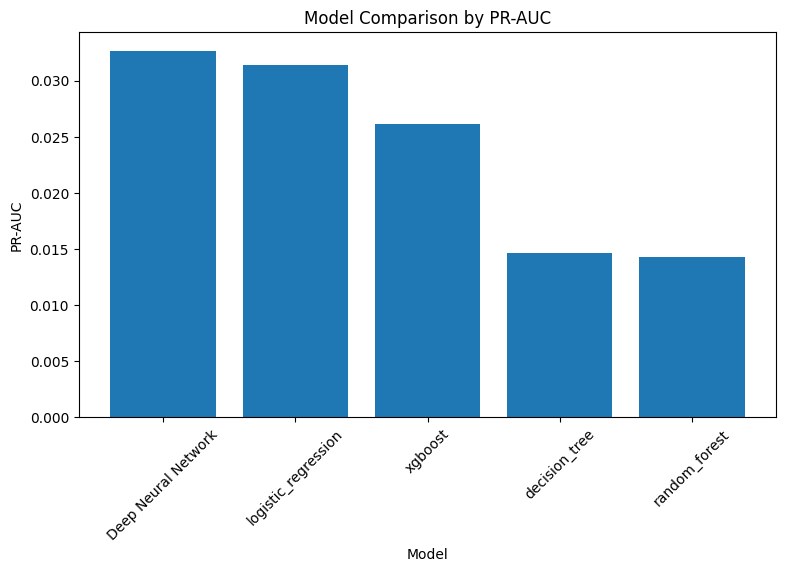

In [21]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["model"],
    results_df["PR_AUC"]
)

plt.title("Model Comparison by PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.xticks(rotation=45)

plt.show()

Precision-Recall Curves

In [22]:
from sklearn.metrics import PrecisionRecallDisplay

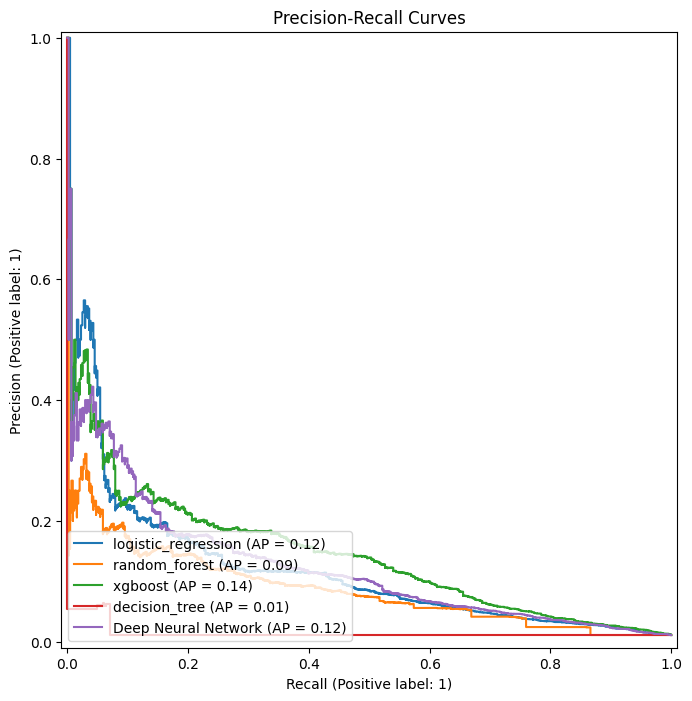

In [25]:
plt.figure(figsize=(8, 8))

for model_name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_prob,
        name=model_name,
        ax=plt.gca()
    )

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_dnn,
    name="Deep Neural Network",
    ax=plt.gca()
)

plt.title("Precision-Recall Curves")
plt.show()

Confusion Matrix — Best Model

In [26]:
best_model_name = "Deep Neural Network"

y_pred_best = y_pred_dnn
y_prob_best = y_prob_dnn

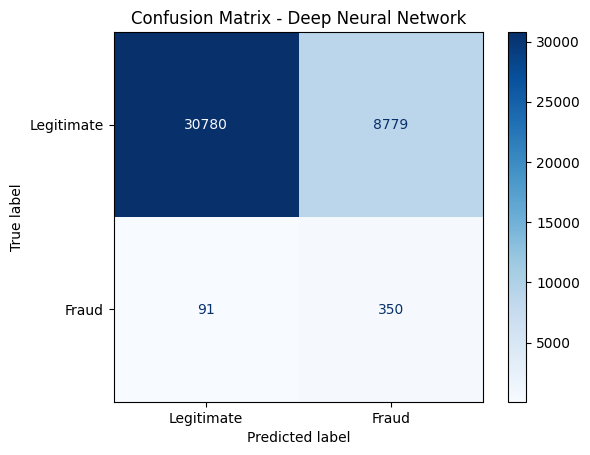

In [27]:
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Deep Neural Network")
plt.show()

Classification Report — Best Model

In [28]:
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.78      0.87     39559
       Fraud       0.04      0.79      0.07       441

    accuracy                           0.78     40000
   macro avg       0.52      0.79      0.47     40000
weighted avg       0.99      0.78      0.87     40000



ROC Curve — Best Model

In [29]:
from sklearn.metrics import RocCurveDisplay

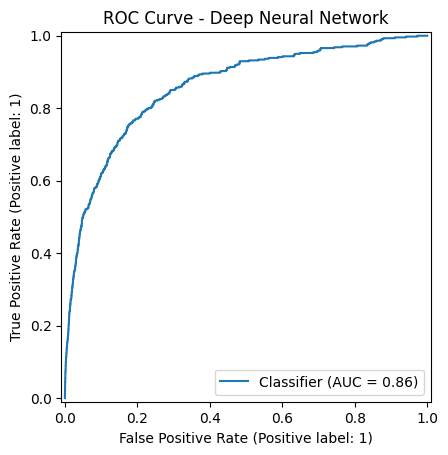

In [30]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best
)

plt.title("ROC Curve - Deep Neural Network")
plt.show()

Final Model Selection

The Deep Neural Network was selected as the final model because it achieved the highest Recall, ROC-AUC and PR-AUC among all evaluated models.

Although tree-based models achieved higher Accuracy, they detected very few fraudulent applications. For a bank account opening fraud detection system, Recall is more important than Accuracy because missing fraudulent applications can create significant financial and operational risk.

The Deep Neural Network is therefore the most suitable model for this project because it identifies a much larger proportion of fraudulent applications and can support manual review prioritisation.